# Implementation of a Variational Quantum Circuit (VQC) for Physics Problems

This notebook implements the hybrid quantum-classical scheme to minimize a cost function based on the meson mass discrepancy.

#### 1. Environment Setup

We installed the necessary libraries. PennyLane is the industry standard for hybrid quantum computing.

In [1]:
#===============================================
# Librerias
#===============================================

# !pip install pennylane numpy matplotlib

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt

### 2. Definition of the Variational Circuit (Ansatz)

Following the Figure, we define the circuit with layers of rotations and entanglement.

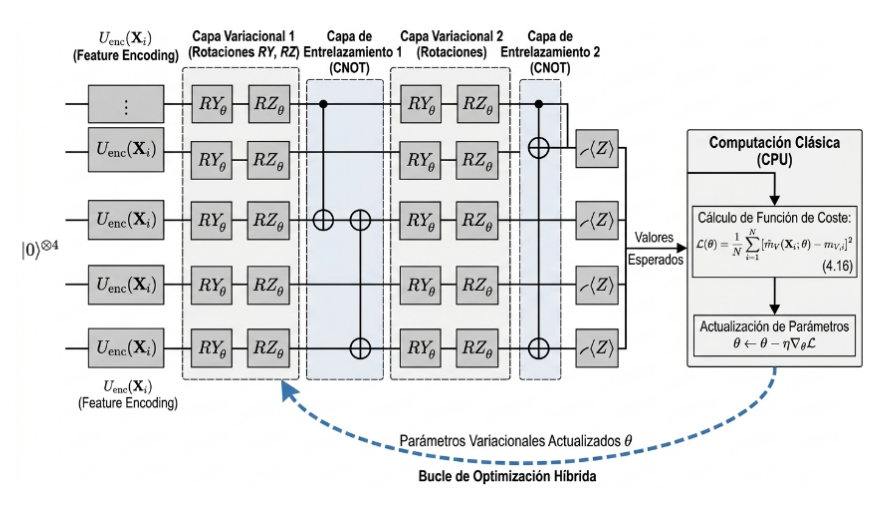

In [2]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def layer(weights):
    # Capa de rotaciones RX, RY, RZ
    for i in range(n_qubits):
        qml.RX(weights[i, 0], wires=i)
        qml.RY(weights[i, 1], wires=i)
    # Capa de entrelazamiento (CNOT)
    for i in range(n_qubits - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def vqc_circuit(params, x):
    # Feature Encoding (U_enc)
    qml.AngleEmbedding(x, wires=range(n_qubits))
    # Capas Variacionales
    for p in params:
        layer(p)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

### 3. Cost Function (MSE)

We implemented Eq. 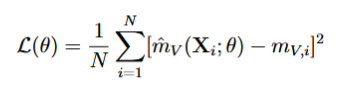

In [3]:
def cost_function(params, x_data, y_targets):
    # Evaluación del circuito para cada punto del conjunto
    predictions = []
    for x in x_data:
        # Usamos la suma de las mediciones como predicción de masa
        predictions.append(np.sum(vqc_circuit(params, x)))
    
    # Cálculo de MSE (Error Cuadrático Medio)
    mse = np.mean((np.array(predictions) - y_targets)**2)
    return mse

### 4. Circuit Visualization

We print the circuit structure to verify the architecture before training.

In [4]:
# Inicialización de parámetros
layers = 2
params = np.random.uniform(0, 2*np.pi, (layers, n_qubits, 2), requires_grad=True)
x_sample = np.random.random(n_qubits)

# Impresión del circuito
print("Arquitectura del Circuito Variacional:")
print(qml.draw(vqc_circuit)(params, x_sample))

Arquitectura del Circuito Variacional:
0: ─╭AngleEmbedding(M0)──RX(5.45)──RY(0.29)─╭●──RX(6.05)──RY(5.44)───────────╭●──────────────┤  <Z>
1: ─├AngleEmbedding(M0)──RX(4.39)──RY(5.43)─╰X─╭●─────────RX(1.87)──RY(2.52)─╰X────────╭●────┤  <Z>
2: ─├AngleEmbedding(M0)──RX(5.52)──RY(3.84)────╰X────────╭●─────────RX(2.56)──RY(6.04)─╰X─╭●─┤  <Z>
3: ─╰AngleEmbedding(M0)──RX(4.16)──RY(0.97)──────────────╰X─────────RX(2.65)──RY(0.39)────╰X─┤  <Z>

M0 = 
[0.43686323 0.70626192 0.96799551 0.90246101]


### 5. Hybrid Training

We simulate the Hybrid Optimization Loop described in the Figure

opt = qml.AdamOptimizer(stepsize=0.1)
x_train = np.random.random((10, n_qubits)) # Dataset simulado
y_train = np.random.random(10)             # Masas objetivo

# Bucle de entrenamiento
for i in range(30):
    params, cost = opt.step_and_cost(lambda p: cost_function(p, x_train, y_train), params)
    if i % 5 == 0:
        print(f"Iteración {i}: Función de Coste L(theta) = {cost:.6f}")

This code exemplifies how the quantum circuit acts as a universal function approximator. The quantum state information ∣ψ(θ)⟩ is processed by the classical optimizer to adjust the parameters θ, thus closing the feedback loop that minimizes the discrepancy between the model's predictions and the system's physical observables. This implementation serves as a basis for integrating more complex Quantum Chromodynamics (QCD) models into modern quantum platforms.